# Acoustic Signal Processing from Fiber Optic Sensor Data

This notebook presents the initial processing of acoustic signals acquired using a fiber optic sensing system based on the Sagnac interferometer.

The objective of this notebook is to:

1. Load and explore the dataset stored in MATLAB format
2. Visualize raw time-domain signals
3. Compute and analyze the Fourier Transform of the signals

The dataset contains multiple measurements under different source positions and experimental conditions.

## 1. Import Required Libraries

In this section, we import the necessary Python libraries for:

- Numerical computation (`NumPy`)
- Loading MATLAB files (`SciPy`)
- Data visualization (`Matplotlib`)

## 2. Load MATLAB Data File

The dataset is stored in a `.mat` file generated in MATLAB.  
We use `scipy.io.loadmat` to load the file into Python.

This file contains multiple 3D arrays representing different experimental conditions.

## 3. Inspect Data Structure

We inspect the contents of the `.mat` file to identify the available variables.

Each variable corresponds to a specific experimental configuration.

## 4. Extract Variables from MATLAB Structure

We extract each dataset and store it as a NumPy array.

Each variable follows the naming convention:

- `data_1_*` → Sensor 1
- `data_2_*` → Sensor 2

The second number represents different experimental conditions.

## 5. Verify Data Dimensions

Each dataset has the following structure:

- 10240 samples per signal
- 13 spatial positions of the acoustic source
- 10 independent measurements

This structure is essential for understanding how to index and process the data.

### Data Structure Description

Each dataset follows a 3D structure:
data[sample, position, measurement]
Where:

- `sample`: time samples (10240 points)
- `position`: spatial location of the source (13 values from -0.15 to 0.15 m)
- `measurement`: repeated experiments (10 trials)

This structure allows statistical and spatial analysis of the acoustic signals.

In [13]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

In [14]:
mat_data = sio.loadmat("processed_signals.mat")
mat_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'data_1_20', 'data_1_30', 'data_1_40', 'data_1_50', 'data_2_20', 'data_2_30', 'data_2_40', 'data_2_50'])

In [15]:
data_1_20 = mat_data["data_1_20"]
data_1_30 = mat_data["data_1_30"]
data_1_40 = mat_data["data_1_40"]
data_1_50 = mat_data["data_1_50"]

data_2_20 = mat_data["data_2_20"]
data_2_30 = mat_data["data_2_30"]
data_2_40 = mat_data["data_2_40"]
data_2_50 = mat_data["data_2_50"]

print(data_1_20.shape)

(10240, 13, 10)


## 6. Select a Signal for Analysis

To simplify visualization, we select:

- One dataset (`data_1_20`)
- One spatial position (central index)
- One measurement

This allows us to analyze a representative signal.

## 7. Define Sampling Parameters

The acquisition system operates at:

- Sampling frequency: 100,000 Hz

We will analyze only the first 1024 samples to improve visualization clarity.

## 8. Generate Time Vector

We create a time vector corresponding to the selected number of samples.

This allows us to represent the signal in the time domain.

## 9. Time Domain Visualization

We plot the raw signal in the time domain.

This visualization helps us observe:

- Signal amplitude variations
- Temporal structure
- Possible noise or oscillatory behavior

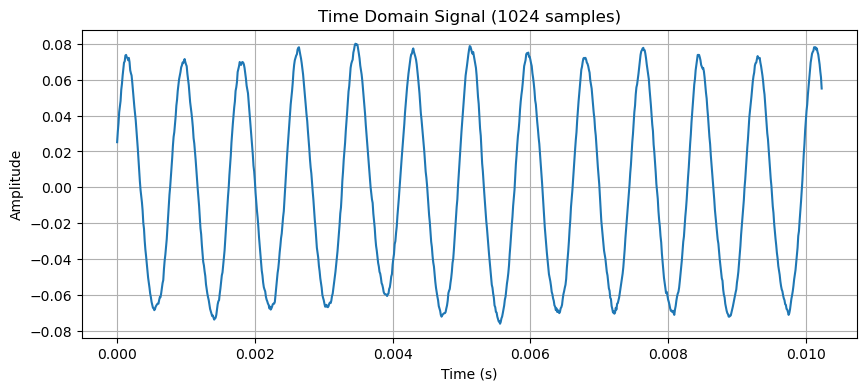

In [ ]:
""" Data dimensions:
        10240 → samples per signal
        13    → source's position (x = -0.15:0.025:0.15)
        10    → intependent measurements
    Structure: 
        data[sample, position, measurement] """

signal = data_1_20[:, 6, 0]
fs = 100000  # Hz
N = 1024     # samples for plotting
t = np.arange(N) / fs
plt.figure(figsize=(10,4))
plt.plot(t, signal[:N])
plt.title("Time Domain Signal (1024 samples)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

## 10. Compute Fourier Transform

We compute the Fast Fourier Transform (FFT) to analyze the frequency content of the signal.

The FFT converts the signal from the time domain into the frequency domain.

## 11. Compute Magnitude Spectrum

We calculate the magnitude of the FFT.

This represents the strength of each frequency component in the signal.

## 12. Generate Frequency Axis

We compute the frequency bins corresponding to the FFT.

This allows us to correctly interpret the spectral components.

## 13. Select Positive Frequencies

Since the FFT is symmetric, we only keep the positive half of the spectrum for visualization.

This simplifies interpretation.

## 14. Frequency Domain Visualization

We plot the magnitude spectrum of the signal.

This allows us to identify:

- Dominant frequencies
- Bandwidth of the signal
- Noise components

## 15. Reusable Visualization Function

To improve reproducibility and modularity, we define a function that:

- Plots the signal in the time domain
- Computes and plots its FFT

This function can be reused for any signal in the dataset.

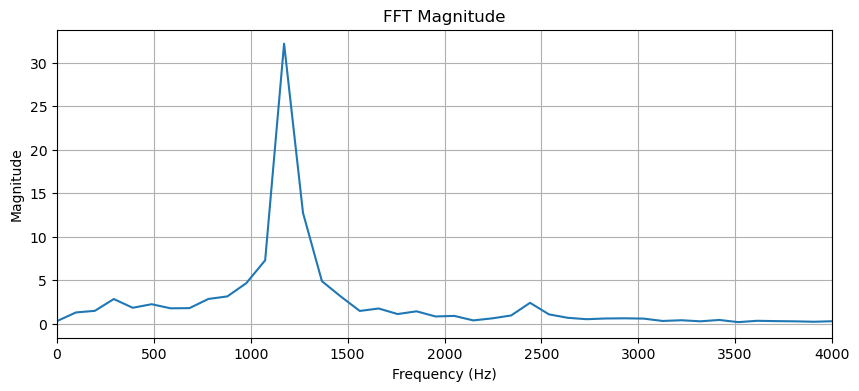

In [19]:
fft_signal = np.fft.fft(signal[:N])
fft_magnitude = np.abs(fft_signal)

freqs = np.fft.fftfreq(N, d=1/fs)

half = N // 2

freqs_pos = freqs[:half]
fft_pos = fft_magnitude[:half]

plt.figure(figsize=(10,4))

plt.plot(freqs_pos, fft_pos)

plt.title("FFT Magnitude")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 4000)
plt.grid()

plt.show()

## Function to plot original signal and fft spectrum

A simplification of points 9-15. 

The function operates: 

plot_signal_and_fft(`signal`, `fs`, `N`)

where:

-`signal` is the full selected signal stored in a vector.

-`fs` is the sampling frequency of the acoustic signal. 

-`N` is the number of samples to create the signal figure. 

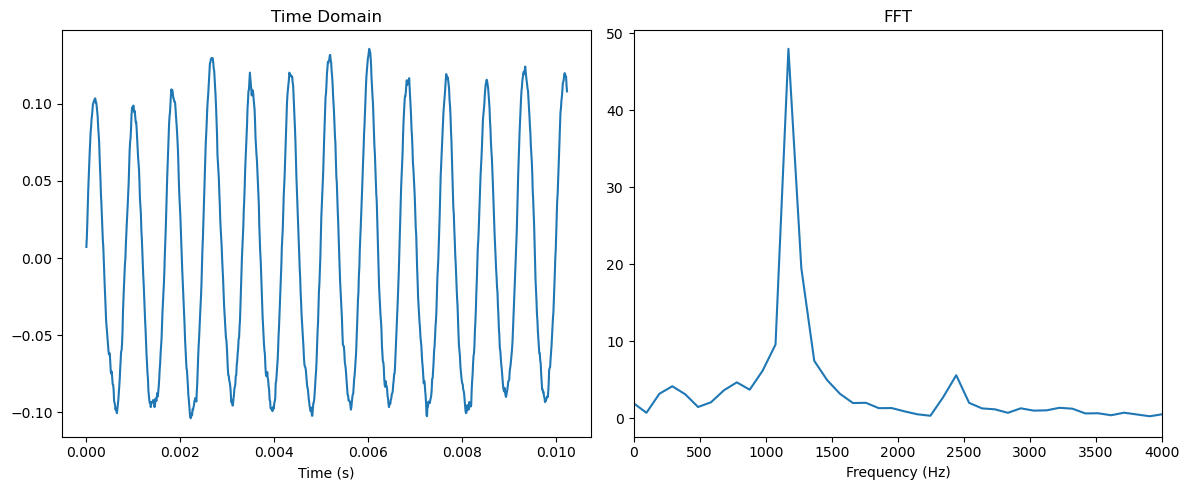

In [25]:
def plot_signal_and_fft(signal, fs, N=1024):
    
    t = np.arange(N) / fs
    
    fft_signal = np.fft.fft(signal[:N])
    fft_magnitude = np.abs(fft_signal)
    freqs = np.fft.fftfreq(N, d=1/fs)
    
    half = N // 2
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(t, signal[:N])
    plt.title("Time Domain")
    plt.xlabel("Time (s)")
    
    plt.subplot(1,2,2)
    plt.plot(freqs[:half], fft_magnitude[:half])
    plt.title("FFT")
    plt.xlabel("Frequency (Hz)")
    plt.xlim(0, 4000)
    plt.tight_layout()
    plt.show()

plot_signal_and_fft(data_2_20[:, 4, 2], fs)